In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [2]:
#Load the data
df = pd.read_csv("customer_segmentation_data.csv")
df.head()

,Customer_ID,Age,Gender,Annual_Income,Avg_Monthly_Spend,Purchase_Frequency,Preferred_Category
0,1,56,Female,395835,3056,5,Electronics
1,2,46,Male,68304,1968,6,Groceries
2,3,32,Female,361593,6289,22,Groceries
3,4,60,Male,112986,7214,4,Beauty
4,5,25,Female,181836,1760,19,Beauty


In [3]:
#Inspect and understand the data
df.info() #non-null count and data type
df.describe() #descriptive stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         300 non-null    int64 
 1   Age                 300 non-null    int64 
 2   Gender              300 non-null    object
 3   Annual_Income       300 non-null    int64 
 4   Avg_Monthly_Spend   300 non-null    int64 
 5   Purchase_Frequency  300 non-null    int64 
 6   Preferred_Category  300 non-null    object
dtypes: int64(5), object(2)
memory usage: 16.5+ KB


,Customer_ID,Age,Annual_Income,Avg_Monthly_Spend,Purchase_Frequency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.810000,253882.000000,4340.556667,12.023333
std,86.746758,13.547164,136297.019592,2216.187460,7.151686
min,1.000000,18.000000,30404.000000,303.000000,1.000000
25%,75.750000,29.000000,139834.750000,2427.250000,6.000000
50%,150.500000,41.500000,246186.500000,4474.000000,11.000000
75%,225.250000,52.000000,370922.750000,6291.000000,19.000000
max,300.000000,64.000000,498888.000000,7987.000000,24.000000


In [98]:
#Select features for segmentation
features = df[[
    "Avg_Monthly_Spend",
    "Purchase_Frequency"
]]

In [99]:
#standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features) #Ensuring that variable are in comparable scale

In [100]:
#decide number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42) #fitting the k-means model, allocating each data point to the closest centroid (cluster)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

D:\Users\BMayongo\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Users\BMayongo\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Users\BMayongo\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Users\BMayongo\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

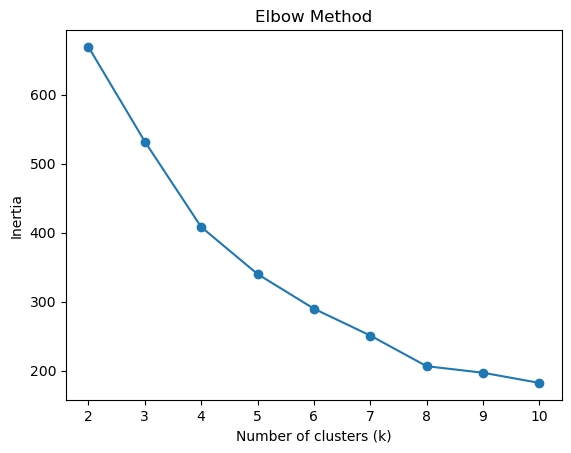

In [20]:
#plot inertia against the k-value in range 2-11
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [112]:
#Fit the cluster model
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters
df.head()

D:\Users\BMayongo\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Customer_ID,Age,Gender,Annual_Income,Avg_Monthly_Spend,Purchase_Frequency,Preferred_Category,Cluster
0,1,56,Female,395835,3056,5,Electronics,2
1,2,46,Male,68304,1968,6,Groceries,2
2,3,32,Female,361593,6289,22,Groceries,3
3,4,60,Male,112986,7214,4,Beauty,0
4,5,25,Female,181836,1760,19,Beauty,1


In [113]:
#Evaluate clustering - How compact the clusters are.
score = silhouette_score(scaled_features, clusters)
score

0.42992176550526123

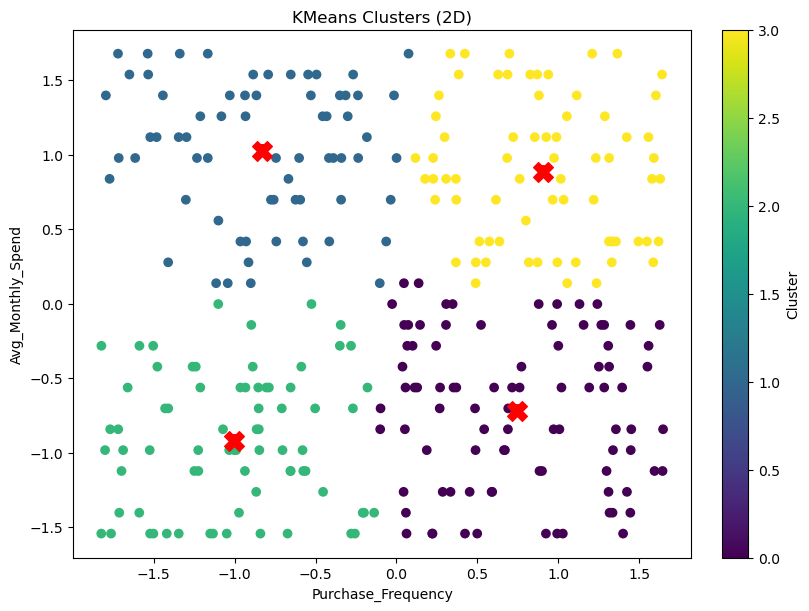

In [114]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Scatter plot (2D)
scatter = ax.scatter(
    scaled_features[:, 0],
    scaled_features[:, 1],
    c=df["Cluster"],
    cmap="viridis"
)

# Plot centroids
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='red',
    marker='X'
)

# === LABEL CENTROIDS ===
for i, c in enumerate(centroids):
    ax.text(
        c[0], c[1],
        str(i),
        color='red',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center'
    )

ax.set_xlabel("Purchase_Frequency")  # Change to actual feature name
ax.set_ylabel("Avg_Monthly_Spend")
ax.set_title("KMeans Clusters (2D)")

plt.colorbar(scatter, label="Cluster")
plt.show()


In [104]:
#Observe the features in each cluster
df.groupby("Cluster")[[
    "Avg_Monthly_Spend",
    "Purchase_Frequency"
]].mean()

,Avg_Monthly_Spend,Purchase_Frequency
Cluster,,
0,5991.438202,6.887640
1,2503.602941,19.323529
2,2120.479452,5.452055
3,6341.271429,18.314286


In [105]:
cluster_summary = df.groupby("Cluster")["Gender"].value_counts(normalize=True)
cluster_summary

Cluster  Gender
0        Female    0.505618
         Male      0.494382
1        Female    0.558824
         Male      0.441176
2        Female    0.534247
         Male      0.465753
3        Female    0.585714
         Male      0.414286
Name: proportion, dtype: float64

In [106]:
cluster_summary = df.groupby("Cluster")["Preferred_Category"].value_counts(normalize=True)
cluster_summary

Cluster  Preferred_Category
0        Home                  0.247191
         Electronics           0.224719
         Clothing              0.202247
         Beauty                0.168539
         Groceries             0.157303
1        Clothing              0.220588
         Electronics           0.220588
         Groceries             0.205882
         Beauty                0.191176
         Home                  0.161765
2        Groceries             0.301370
         Electronics           0.260274
         Clothing              0.178082
         Beauty                0.136986
         Home                  0.123288
3        Home                  0.314286
         Clothing              0.228571
         Electronics           0.185714
         Groceries             0.157143
         Beauty                0.114286
Name: proportion, dtype: float64